In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import os
import squidpy as sq
import spatialdata as sd
import spatialdata_io as sio
import spatialdata_plot

/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  fro

1.2.1 Download data and convert to zarr format
This step may take some time, as the Xenium Prime Breast Cancer output bundle is 41GB in size. For convenience, we've included a smaller Zarr file in the next section. If you'd like to generate this smaller Zarr file yourself, simply uncomment and run the code provided below.

Important note: The Zarr format used by spatialdata differs from the format used in the Xenium bundle. To take full advantage of spatialdata’s optimizations, you must convert the Xenium bundle Zarr to the spatialdata Zarr format. The commented code below demonstrates how to perform this conversion. For more details, please refer to Xenium spatialdata tutorial.

In [ ]:
# https://www.10xgenomics.com/analysis-guides/xenium-downstream-analysis-in-python-tutorial

In [3]:
# !wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/breast.zarr.zip
# !unzip breast.zarr.zip
# !rm breast.zarr.zip

## 2.2 Loading objects for Xenium data

In [2]:
sdata = sd.read_zarr('breast.zarr/') # old format of zarr, save and read it to update the format

sdata

/tmp/ipykernel_21689/2829433524.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr('breast.zarr/') # old format of zarr, save and read it to update the format
no parent found for <ome_zarr.reader.Label object at 0x7f1a8f6ad510>: None
no parent found for <ome_zarr.reader.Label object at 0x7f1a8f6aea50>: None
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /stomics_data/liminData/spatial_related_codes/spatial_biology/Xenium/breast.zarr
├── Labels
│     ├── 'cell_labels': DataTree[yx] (74945, 51265), (37472, 25632), (18736, 12816), (9368, 6408), (4684, 3204)
│     └── 'nucleus_labels': DataTree[yx] (74945, 51265), (37472, 25632), (18736, 12816), (9368, 6408), (4684, 3204)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (699110, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (699110, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (692184, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (699110, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

# 2.3 Transcript and cell plotting functions for Xenium data

The "cell_boundaries" shapes point us to the spatial locations and shape of the cells, while the "table" object points us to the gene expression. We need to link them together with the function set_table_annotates_spatialelement. For cells, the plotting function is render_shapes, while for transcripts, the function is render_points. For more detailed, please refer to the official spatialdata plotting documentation.

AnnData object with n_obs × n_vars = 699110 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


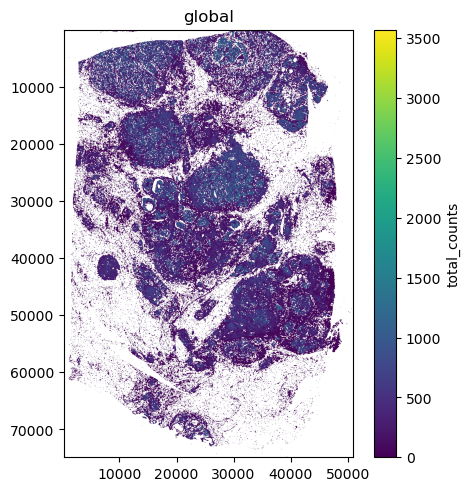

In [4]:
print(sdata.tables['table'])
sdata.tables["table"].obs["region"] = "cell_boundaries"

# link "shapes (the spatial location and shape of the cells)" and "table (the gene expression)"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# cells plotting function: The x and y axis are pixel coordinates
sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/dask/dataframe/core.py:3769: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting string to object dtype.
  warnings.warn(
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/dask/dataframe/core.py:3769: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting string to object dtype.
  warnings.warn(


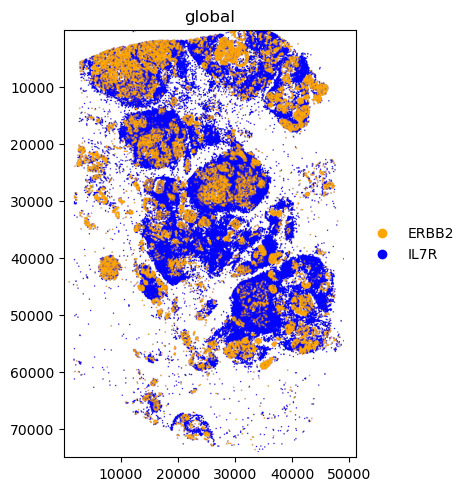

In [13]:
# Alternatively, spatialadata allows us to plot two or more transcripts on the same tissue.

sdata.pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ERBB2", "IL7R"],
    palette=["orange", "blue"]
).pl.show()





# 2.4 Select sub-region of interest
There are two ways to select sub_regions of interest
1. By coordinates
2. By cell IDs




In [18]:
# Note: `sdata.tables['table']` is anndata, `sdata.tables` is not.
print(sdata.tables)
sdata.tables['table'].obs 


{'table': AnnData object with n_obs × n_vars = 699110 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'}


,cell_id,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,region,z_level,cell_labels
0,aaaaaohf-1,557,0,0,0,0,89,646,220.723758,108.871723,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,1
1,aaaabkoj-1,832,0,0,0,0,148,980,363.914232,91.892972,2.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,2
2,aaaafefl-1,544,0,0,0,0,119,663,181.392663,114.155004,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,3
3,aaaahfjm-1,703,0,0,0,0,116,819,279.426885,81.010315,2.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,4
4,aaaahjao-1,207,0,0,0,0,30,237,75.094846,52.607033,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699105,oimkalkm-1,3,0,0,0,0,6,9,18.875313,18.875313,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,7.0,699106
699106,oimkankb-1,0,0,0,0,0,1,1,12.508282,6.863750,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,7.0,699107
699107,oimkapok-1,2,0,0,0,0,4,6,49.897658,8.534532,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,7.0,699108
699108,oimkbcmb-1,4,0,0,0,0,0,4,16.752969,8.624844,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,6.0,699109


In [15]:
# sub-region coordinates
#!wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/Selection_1_coordinates.csv

In [5]:
%time
from spatialdata import polygon_query

def crop0(x, polygon):
    return polygon_query(
        x,
        polygon,
        target_coordinate_system="global"

    )

polygon = sio.xenium_explorer_selection("Selection_1_coordinates.csv")
cropped_sdata = crop0(sdata, polygon)


CPU times: user 9 μs, sys: 1e+03 ns, total: 10 μs
Wall time: 21.9 μs


In [22]:
cropped_sdata.tables['table'].obs

,cell_id,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,region,z_level,cell_labels
5793,abpakhij-1,41,0,0,0,0,14,55,30.796564,18.062501,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,5794
5794,abpanbni-1,30,0,0,0,0,9,39,35.086408,17.385157,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,5795
5795,abpanoof-1,32,0,0,0,0,2,34,45.382033,23.797345,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,5796
5796,abpapdko-1,29,0,0,0,0,3,32,45.336877,23.436095,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,5797
5797,abpbapln-1,27,0,0,0,0,10,37,40.189064,21.087970,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_boundaries,0.0,5798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686131,oeiabgon-1,1,0,0,0,0,0,1,138.945786,11.424532,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,7.0,686132
686132,oeiacnkf-1,5,0,0,0,0,5,10,73.740159,8.082969,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,5.0,686133
686133,oeiadoal-1,6,0,0,0,0,6,12,134.475317,9.844063,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,7.0,686134
686134,oeiaflpp-1,1,0,0,0,0,0,1,89.273909,8.534532,1.0,Segmented by nucleus expansion of 5.0µm,cell_boundaries,6.0,686135


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


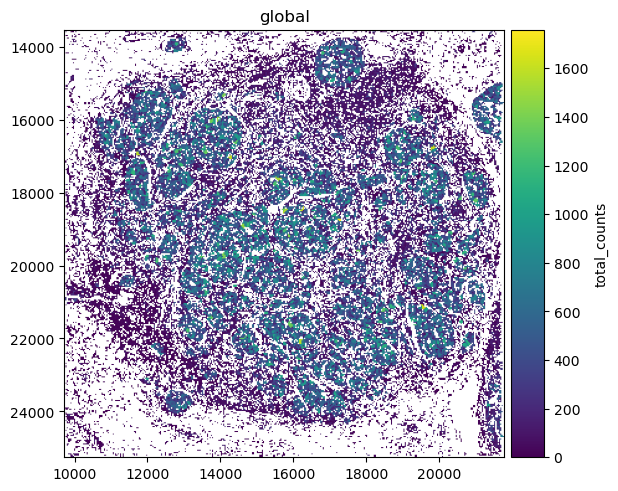

In [23]:
# plot the subsetted region -- safety check code of the two below, making sure the table abd shape is linked.
cropped_sdata.tables["table"].obs["region"] = "cell_boundaries"
cropped_sdata.set_table_annotates_spatialelement("table", region = "cell_boundaries")

cropped_sdata.pl.render_shapes("cell_boundaries", color = "total_counts").pl.show()




In [18]:
# 2.4.2 Select sub-region by cell IDs
!wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/one-sample-analysis.tar.gz
!tar -xzvf ./one-sample-analysis.tar.gz



--2026-02-11 21:09:18--  https://cf.10xgenomics.com/supp/xenium/analysis-workshop/one-sample-analysis.tar.gz
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1917425125 (1.8G) [application/x-tar]
Saving to: ‘one-sample-analysis.tar.gz’

100%[====================================>] 1,917,425,125 97.4MB/s   in 28s    

2026-02-11 21:09:47 (65.6 MB/s) - ‘one-sample-analysis.tar.gz’ saved [1917425125/1917425125]

./one-sample-analysis/
./one-sample-analysis/Xenium_Prime_Breast_Cancer_FFPE_outs/
./one-sample-analysis/Xenium_Prime_Breast_Cancer_FFPE_outs/cell_feature_matrix/
./one-sample-analysis/Xenium_Prime_Breast_Cancer_FFPE_outs/cell_feature_matrix/matrix.mtx.gz
./one-sample-analysis/Xenium_Prime_Breast_Cancer_FFPE_outs/cell_feature_matrix/features.tsv.gz
./one-sample-analysis/Xenium_Prime_Brea

In [24]:
select_cells = pd.read_csv(
    "./one-sample-analysis/Selection_1_cells_stats.csv",skiprows=2
)

select_cells.head()

,Cell ID,Cluster,Transcripts,Area (µm^2)
0,eaedgfpo-1,Cluster 2,0,35.69
1,dchjbpll-1,Cluster 11,0,158.68
2,dbndddjb-1,Cluster 5,0,26.42
3,iepagjon-1,Cluster 12,0,23.59
4,odblddca-1,Cluster 25,0,23.06


In [25]:
sdata['table']

AnnData object with n_obs × n_vars = 699110 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [26]:
subset_sdata = sd.match_sdata_to_table(
    sdata,
    table = sdata['table'][sdata["table"].obs["cell_id"].isin(select_cells["Cell ID"])],
    table_name = "table",
    how="right"
)

/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/spatialdata/models/models.py:1182: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[cls.ATTRS_KEY] = attr


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


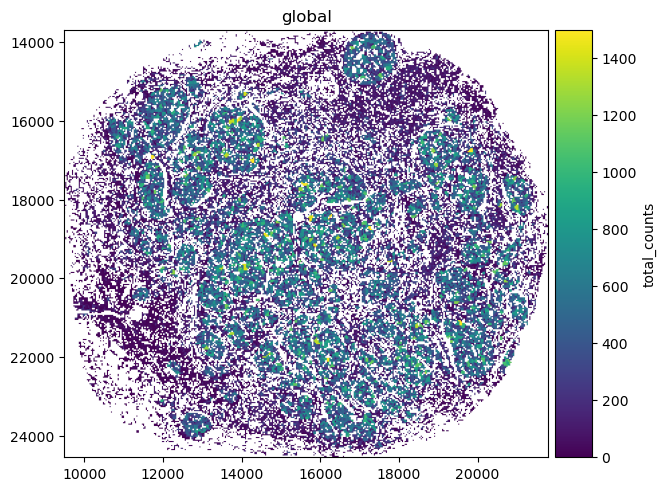

In [27]:
# Clipping the data for the plotting to be more obvious
import matplotlib.colors as mpc

norm = mpc.Normalize(vmin=0, vmax=1500, clip=True)

subset_sdata.pl.render_shapes(
    "cell_boundaries", color="total_counts", norm=norm
).pl.show()



## Section 2.5 Downstream Xenium data analysis of count matrix (`sdata['table']`)

The `sdata['table']` is a regular anndata object, which is commonly used in single cell analysis. AnnData is specifically designed for matrix-like data. We have n observations(cells), each of which can be represented as d-demensional vectors (genes).

The first step is QC. We want to remove cells with low transcript counts. Here we plot the distribution of transcript counts per cell in a histogram to determine the transcript count cutoff to remove cells with low transcript counts. The determination of lower cutoff can be subjective. There is no gold-standard rule.

We shallow copy with the step adata = sdata['table]. Any changes made in adata will be reflected in sdata['table]. To make a separate adata object, run adata = sdata['table']copy().


In [28]:
# Section 2.5.2 Standard data preprocessing
adata = sdata["table"] # Creates a reference (a pointer), not a deep copy. This guaranttees all the analysis performed on adata later will be in sdata. In the end, just save sdata, instead of saving adata.
# We store the counts in the layers in case we need it for future purposes. In this analysis guide, we don't use it.
adata.layers["counts"] = adata.X.copy()

Text(0, 0.5, 'Number of cells')

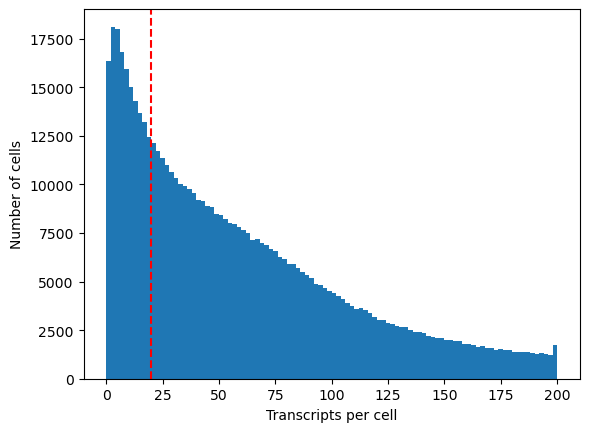

In [29]:
# Plot histogram before filtering
fig = plt.hist(adata.obs["total_counts"], range=(0, 200), bins=100)
plt.axvline(x=20, color="r", linestyle="--")  # You can customize color and linestyle

plt.xlabel("Transcripts per cell")
plt.ylabel("Number of cells")

In [30]:
# Based on the histogram plot, here we choose 20 transcript counts as lower cutoff
thres = np.quantile(adata.obs["total_counts"], 0.98)
sc.pp.filter_cells(adata, min_counts=20)
sc.pp.filter_cells(adata, max_counts=thres)

# We also filter out genes that are rarely expressed
sc.pp.filter_genes(adata, min_cells=100)

Next, we find top 2k variable genes in this Xenium Prime data. If you are analyzing Xenium v1 panel data, it's impossible to have top 2k variable genes. In that case, you can use all genes in the panel.

The following code is for Xenium Prime data (>5k genes). Here, we used Seurat's highly variable methodology, but there are other highly variable genes flavours

In [31]:
%%time
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)

CPU times: user 1.85 s, sys: 53.2 ms, total: 1.9 s
Wall time: 791 ms


We proceed with the usual single cell workflow. We first log-normalized the data, and store the log-normalized data in a layer called "lognorm". The "lognorm" data is important for downstream analysis as a lot of the functions work with log-normalized data. Alternatively, you can store it such as adata.raw = adata.copy().

In [32]:
%%time
# Log Normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy() # this data can be used for DEG

CPU times: user 431 ms, sys: 15.9 ms, total: 447 ms
Wall time: 308 ms


In [33]:
%%time
"""
When you set zero_center=False, the scale function performs unit variance scaling without shifting the mean of your data.
What it actually does:
Normally, "scaling" (Z-score) does two things:
Centers: Subtracts the mean from each gene (making the mean 0).
Scales: Divides each gene by its standard deviation (making the variance 1).
By setting `zero_center=False`, you skip step 1 and only perform step 2. Every value in a gene's profile is divided by that gene's standard deviation.

Why do this? (The "Why")
The primary reason is Sparsity.
Memory Efficiency: Single-cell data is "sparse" (mostly zeros). If you subtract the mean (centering), every single zero becomes a negative number (e.g., 
). This "densifies" the matrix, often causing it to take up 10x to 50x more RAM, which can crash your session.
Preserving Zeros: Keeping zeros as zeros is helpful for certain downstream algorithms or simply to save memory while still ensuring that highly variable genes and lowly variable genes are on the same numerical scale (variance = 1).
What about max_value=10?
This is "clipping." After dividing by the standard deviation, any value higher than 10 is reset to 10. This prevents extreme outliers (like one cell with massive technical noise) from dominating your PCA or clustering.

"""
# Scaling of data, we don't center the data here as the data centering is done in PCA and this keeps the X sparse for memory efficiency.



sc.pp.scale(adata, zero_center=False, max_value=10)

CPU times: user 986 ms, sys: 23.6 ms, total: 1.01 s
Wall time: 186 ms


In [35]:
%%time
""" 
In sc.pp.neighbors, the metric defines how Python calculates the "distance" (similarity) between two cells in high-dimensional space.
When you choose metric="cosine", you are telling Scanpy to measure the angle between cell expression vectors rather than the straight-line distance between them.
What it actually does:
Direction over Magnitude: Cosine similarity cares about the ratio of gene expression, not the absolute total counts. If Cell A and Cell B have the same expression pattern, but Cell A has twice as many total reads, cosine will see them as nearly identical.
Normalization: It effectively normalizes each cell's vector to a length of 1 before calculating the distance.
Formula: It calculates the cosine of the angle 
 between two vectors. A value of 1 (angle of 0°) means they are perfectly aligned, while 0 (angle of 90°) means they share no similarities.
Why use it instead of the default ("euclidean")?
Batch/Tech Effects: In single-cell data, some cells have higher "sequencing depth" (more total UMI counts) purely for technical reasons. Euclidean distance is very sensitive to this; Cosine distance is not.
High Dimensionality: As the number of genes (dimensions) increases, Euclidean distance often becomes less meaningful (the "curse of dimensionality"). Cosine distance often stays more robust for finding true biological neighbors.
Sparsity: Cosine distance is generally very effective at handling sparse matrices where many values are zero.

When to use it:
Use cosine if you haven't perfectly normalized your total counts per cell and want to focus on the expression profile shape.
Use euclidean (default) if you have already scaled and centered your data (as you did with sc.pp.scale) and want to account for the absolute differences in scaled values.
Since you just ran sc.pp.scale(zero_center=False), using cosine is a common and valid choice to ensure that "size" differences don't drive your clusters.

"""

# PCA for dimension reduction further by UMAP for downstream analysis
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, metric="cosine", random_state=42)
# clustering with leiden. We use igraph here as it scales better. The resolution is a hyper-parameter. A higher resolution will output more clusters.
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=0.5)

CPU times: user 3min 3s, sys: 6.62 s, total: 3min 10s
Wall time: 3min 4s


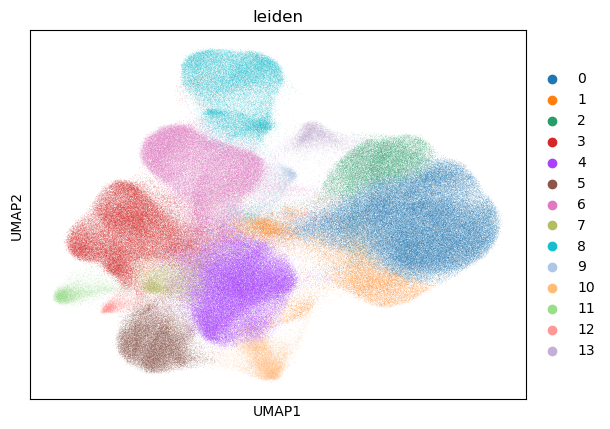

CPU times: user 41min 43s, sys: 23 s, total: 42min 6s
Wall time: 11min 9s


In [36]:

%%time
# RUN UMAP
############### SKIP these steps for in-person events ###################
sc.tl.umap(adata, random_state=42)
sc.pl.umap(adata, color="leiden")

In [37]:
# Section 2.5.3 Plot clustering results spatially in slide

sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

#sdata.pl.render_shapes("cell_boundaries", color="leiden").pl.show(figsize=(12.8, 9.6)) # not enough memory to plot this one.



/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


In [42]:
# Section 2.5.4 Export clustering results and visualize in Xenium Explorer
# the csv file can be uploaded to Xenium explorer
clustering_res = adata.obs[["cell_id", "leiden"]]
clustering_res.columns = ["cell_id", "group"]
print(clustering_res.head())

clustering_res.to_csv("clustering_res.csv", index=False)

      cell_id group
0  aaaaaohf-1     0
2  aaaafefl-1     1
4  aaaahjao-1     0
5  aaaajdej-1     0
6  aaaakcik-1     0


# Section 2.5.5 Find marker genes for each cluster for cell annotation
Use Scanpy's function sc.tl.tl_genes_group to identify marker genes in each cluster. By setting pts=True, it returns the percentage of cells that expresses each gene. In Scanpy, the functions are very flexible, and is up to the user to provide the right data. For sc.tl.rank_gene_groups, it expects log-normalized data, therefore we set the layer = "lognorm" here.

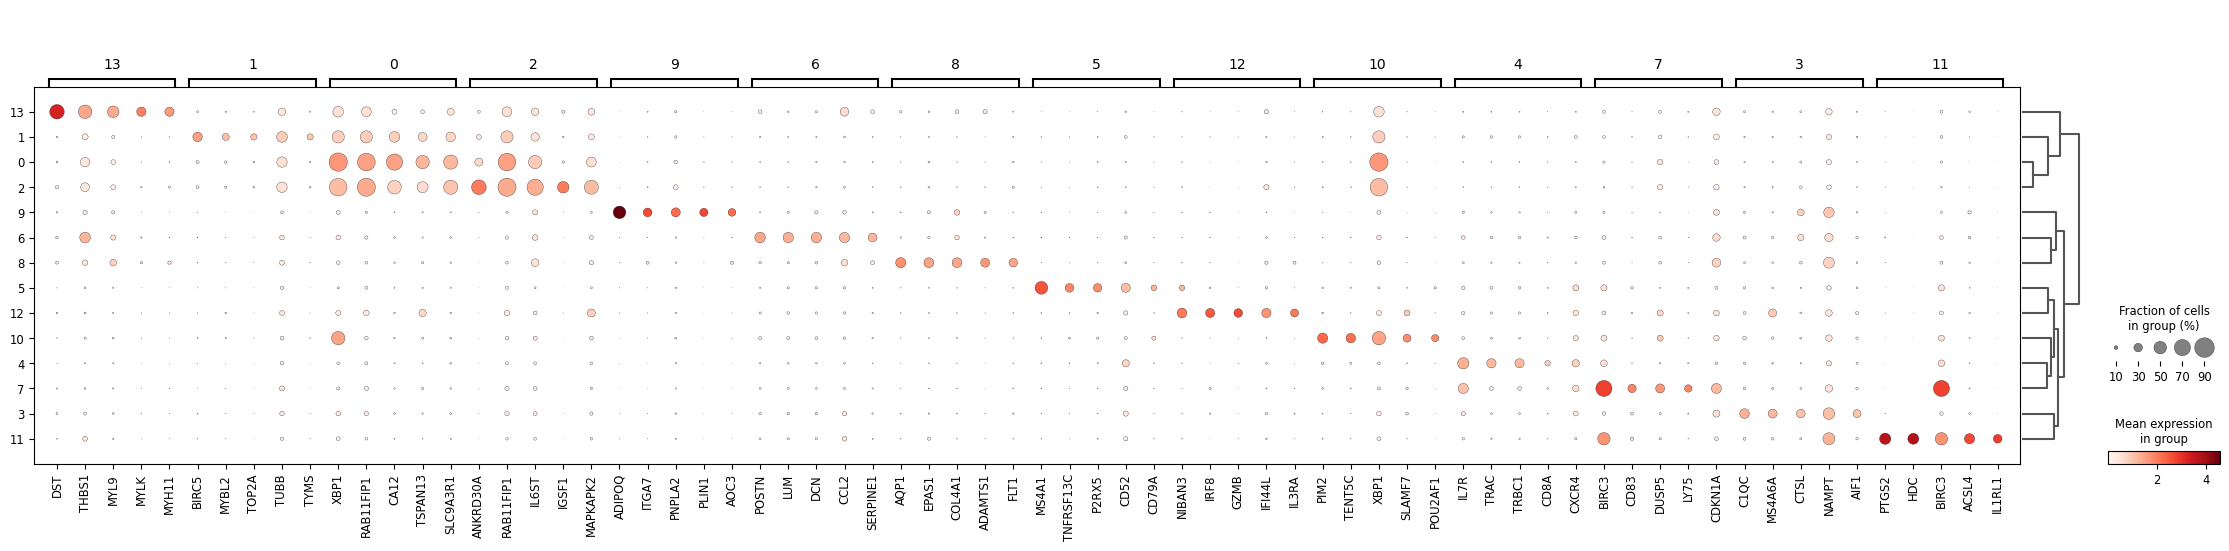

In [43]:
sc.tl.rank_genes_groups(adata, groupby="leiden", layer="lognorm", pts=True)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)



In [44]:
# Section 2.5.6 Cell annotation based on marker genes in each cluster
"""  
Based on marker genes in each cluster, we can identify each cell type.
Here we are sharing one possible way to annotate each cluster.
Step 1. Get marker genes in each cluster.
Step 2. Find cell type that is highly associated with the provided marker genes via third-party tools, such as Enrichr.
Step 3. Check spatial location of that cluster in Xenium Explorer (together with H&E image if any) and confirm its cell identity (some clusters' cell identities can be further supported by their spatial locations, such as tumor, vascular endothelial, etc).
Making "endothelial" (cluster 11) as an example below:

"""

sdata.tables["table"].obs.dtypes
type(sdata.tables["table"].obs.index._values)



numpy.ndarray

In [49]:
# Section 2.5.7 Saving the processed data --We can save the zarr format for further processing
import pandas as pd

sdata.write("breast_processed.zarr", overwrite=True)


/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/zarr/core/dtype/npy/structured.py:318: UnstableSpecificationWarning: The data type (Structured(fields=(('0', FixedLengthUTF32(length=25, endianness='little')), ('1', FixedLengthUTF32(length=25, endianness='little')), ('2', FixedLengthUTF32(length=25, endianness='little')), ('3', FixedLengthUTF32(length=25, endianness='little')), ('4', FixedLengthUTF32(length=25, endianness='little')), ('5', FixedLengthUTF32(length=25, endianness='little')), ('6', FixedLengthUTF32(length=25, endianness='little')), ('7', FixedLengthUTF32(length=25, endianness='little')), ('8', FixedLengthUTF32(length=25, endianness='little')), ('9', FixedLengthUTF32(length=25, endianness='little')), ('10', FixedLengthUTF32(length=25, endianness='little')), ('11', FixedLengthUTF32(length=25, endianness='little')), ('12', FixedLengthUTF32(length=25, endianness='little')), ('13', FixedLengthUTF32(length=25, endianness='little'))))) does not have a Zarr V3 spec

In [50]:
sdata['table'].obs

AnnData object with n_obs × n_vars = 495704 × 5085
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatialdata_attrs', 'hvg', 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'rank_genes_groups', 'dendrogram_leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'distances', 'connectivities'

## Annotate the clusters using Enrichr.

# Xenium Prime multi-sample integration using sketch and Harmony

Here, we are using two Xenium Prime datasets generated from the same Xenium gene panel. We recommend integration of Xenium data generated from the same gene panel. The integration of Xenium data generated from different Xenium gene panels is not recommended, since gene probe sets and codewords differ between gene panels.

The two Xenium datasets used in this sections are:
    1. Human breast cancer Xenium Prime data
    2. Human cervical cancer Xenium Prime data

The analysis goal of the integration between breast and cervical cancer Xenium Prime data is to identify whether macrophages in these two cancer types could potentially have different functional roles.

Xenium data can be large. These two datasets (breast and cervical cancer) have in total more than 1.5 million cells. Currently, the on-disk(out-of-core) preprocessubg pipeline for python is still experimental.   
Users who are interested in on-disk preprocessing can refer to scanpy's dask tutorial on how to do on-disk preprocessing. However, many of scanpy's functions are still not currently supported in dask.

To manage memory in this section, we keep the main matrix(adata.X) sparse to be memory efficient.

## Section 3.1 Downloading breast and cervical Xenium Prime data
Here we will need cell_feature_matrix.h5 from both breast and cervical Xenium Prime outputs. We are downloading these two files for demo. This file can be easily found in Xenium output bundle.

Human breast cancer Xenium Prime: ./human_breast_xenium/cell_feature_matrix.h5
Human cervical cancer Xenium Prime: ./human_cervical_xenium/cell_feature_matrix.h5



In [51]:
! wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/multi-sample-analysis.tar.gz
! tar -xzvf ./multi-sample-analysis.tar.gz

--2026-03-11 13:26:28--  https://cf.10xgenomics.com/supp/xenium/analysis-workshop/multi-sample-analysis.tar.gz
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 181630430 (173M) [application/x-tar]
Saving to: ‘multi-sample-analysis.tar.gz’

100%[======================================>] 181,630,430 83.3MB/s   in 2.1s   

2026-03-11 13:26:30 (83.3 MB/s) - ‘multi-sample-analysis.tar.gz’ saved [181630430/181630430]

./multi-sample-analysis/
./multi-sample-analysis/human_breast_xenium/
./multi-sample-analysis/human_breast_xenium/cell_feature_matrix.h5
./multi-sample-analysis/human_breast_xenium/features.tsv.gz
./multi-sample-analysis/human_cervical_xenium/
./multi-sample-analysis/human_cervical_xenium/cell_feature_matrix.h5
./multi-sample-analysis/human_cervical_xenium/features.tsv.gz
./multi-sampl

In [4]:
adata_breast = sc.read_10x_h5("./multi-sample-analysis/human_breast_xenium/cell_feature_matrix.h5")
adata_cervical = sc.read_10x_h5("./multi-sample-analysis/human_cervical_xenium/cell_feature_matrix.h5")




In [5]:
""" 
Since there are multiple samples in this demo, it's a good practice to make cell IDs unique across all integrated samples. Here, we add suffix to cell IDs. For example, we add "_breast" suffix to each cell ID in breast cancer data and "_cervical" suffix to each cell ID in cervical cancer data.
"""
adata_breast.obs_names = adata_breast.obs_names + "_breast"
adata_cervical.obs_names = adata_cervical.obs_names + "_cervical"
adata_breast.obs["tissue"] = "breast"
adata_cervical.obs["tissue"] = "cervical"



In [6]:
# Section 3.2 Conventional data processing by processing in memory

""" 
For this section, we will first combine the breast and cervical Xenium dataset, followed by the same preprocessing done in Section 2.
"""

adata = ad.concat([adata_breast, adata_cervical])
adata


AnnData object with n_obs × n_vars = 1539497 × 5101
    obs: 'tissue'

In [7]:
%%time
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)

CPU times: user 37.1 s, sys: 4.1 s, total: 41.2 s
Wall time: 14.3 s


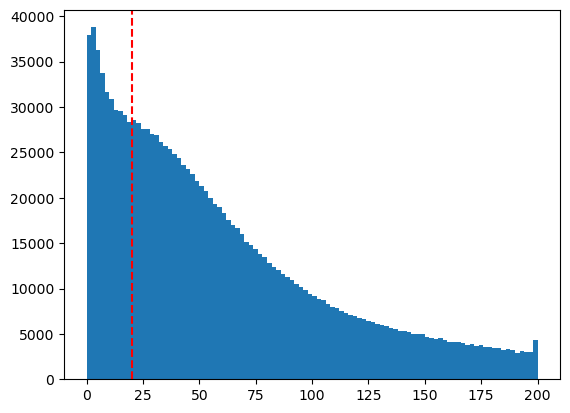

In [8]:
""" 
The preprocessing follows the exact steps in Section 2. The first step is QC. We want to remove cells with low transcript counts. Here we plot the distribution of transcript counts per cell in a histogram to decide the lower cutoff in transcript counts (aiming to remove cells with low transcript counts). The determination of lower cutoff can be subjective. There is no gold-standard rule.
"""
fig = plt.hist(adata.obs["total_counts"], range=(0, 200), bins=100)
plt.axvline(x=20, color="r", linestyle="--") # You can customize color and linestype





In [9]:
%%time
thres = np.quantile(adata.obs["total_counts"], 0.98)
sc.pp.filter_cells(adata, min_counts=20)
sc.pp.filter_cells(adata, max_counts=thres)

sc.pp.filter_genes(adata, min_cells=100)




CPU times: user 2.97 s, sys: 3.03 s, total: 6 s
Wall time: 6.01 s


In [10]:
# Again, we store the counts layer in the anndata object
adata.layers["counts"] = adata.X.copy()



In [11]:
%%time
sc.pp.highly_variable_genes(
    adata, flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts"
)



CPU times: user 3.56 s, sys: 568 ms, total: 4.12 s
Wall time: 1.97 s


In [12]:
%%time
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()



CPU times: user 994 ms, sys: 1.1 s, total: 2.09 s
Wall time: 1.62 s


In [13]:
%%time
sc.pp.scale(
    adata,
    zero_center=False,
    max_value=10
)

sc.pp.pca(adata, n_comps=30, random_state=42)



CPU times: user 22.8 s, sys: 1.44 s, total: 24.3 s
Wall time: 14.6 s


## Section 3.3 Sketching of data for faster visualization (Optional)

Sketching downsamples the data while aiming to retain the rarer cell types. We use this sketched data to generate a downsampled UMAP later for a quicker visualization. This is unlike Seurat's sketch analysis in R, where the downstream analysis is done on the sketched data. You can choose to skip this step to generate the UMAP on the original dataset.



In [6]:
%%time
import geosketch as gs 

N = 5000 # Number of samples to obtain from the data set
sketch_index = gs.gs(adata.obsm["X_pca"], N, replace=False)




CPU times: user 2min 36s, sys: 1.93 s, total: 2min 38s
Wall time: 2min 38s


# Section 3.4 Batch correction with Harmony

Before doing batch correction, we can check if there are significant batch effects between these two data: project cells in 2D UMAP space without any batch correction and visualize cells by their sample origins. If most of cell types are very well separated between samples in UMAP space, it could indicate batch effects.



In [19]:
%%time
adata_sketch = adata[sketch_index]
sc.pp.neighbors(adata_sketch, metric="cosine")
sc.tl.umap(adata_sketch)




CPU times: user 33 s, sys: 637 ms, total: 33.6 s
Wall time: 32.6 s


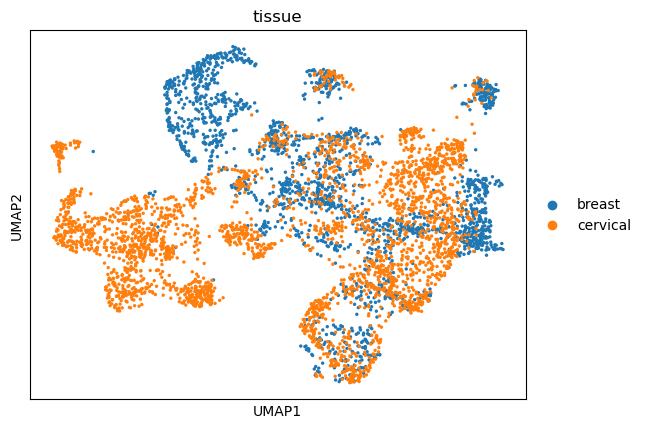

In [20]:
# visualize tissue to see if there is batch-effect
sc.pl.umap(adata_sketch, color="tissue")

"""   
If there are significant batch effects, we can use Harmony to correct batch effects. In this demo, we continue doing batch correction using Harmony. Harmony will correct PCA space (which contains variations from batch effects). After removing batch effects, Harmony will generate new corrected reduced-dimension results. It is labeled as X_pca_harmony and accessed via adata.obsm["X_pca_harmony"].
"""

In [37]:
print(adata.obsm["X_pca"].shape)
print(adata.obs.shape)
print(adata.obs["tissue"].value_counts())

(1182865, 30)
(1182865, 10)
tissue
cervical    702183
breast      480682
Name: count, dtype: int64


In [49]:
# %%time
# ############### SKIP these steps for in-person events ###################
# # Please note that the harmony is ran on the original data and not the sketched data
# # sc.external.pp.harmony_integrate(adata, key="tissue")

# # Convert the metadata to a DataFrame explicitly and run Harmony manually:
# import harmonypy as hm
# X = adata.obsm["X_pca"]
# meta = adata.obs[["tissue"]]

# ho = hm.run_harmony(X, meta, "tissue")
print(ho.Z_corr.shape)
adata.obsm["X_pca_harmony"] = ho.Z_corr
print(adata.obsm["X_pca_harmony"].shape)

(1182865, 30)
(1182865, 30)


In [34]:
# # Load processed data
# # Load processed data if you skip the above step
# # Uncomment this code if you did not run the Harmony in the previous step
# !wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/breast_cervical_adata.h5ad

adata = sc.read_h5ad("breast_cervical_adata.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 1182865 × 5092
    obs: 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [7]:
%%time
adata_sketch = adata[sketch_index]
sc.pp.neighbors(adata_sketch, use_rep="X_pca_harmony", metric="cosine")
sc.tl.umap(adata_sketch, random_state=42)




CPU times: user 33.9 s, sys: 1.01 s, total: 34.9 s
Wall time: 33.8 s


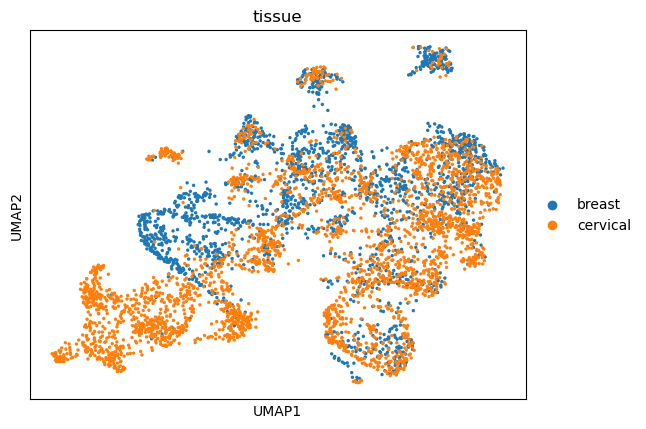

In [8]:
sc.pl.umap(adata_sketch, color="tissue")

In [35]:
%%time
sc.pp.neighbors(adata, use_rep="X_pca_harmony", metric="cosine")
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=1.2)



CPU times: user 7min 27s, sys: 14.8 s, total: 7min 42s
Wall time: 7min 34s


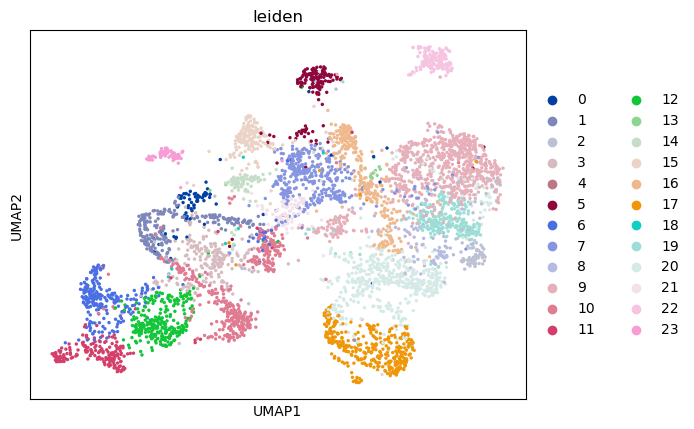

In [36]:
# We assign the cluster labels from the full dataset to the sketched adata object for plotting
adata_sketch.obs["leiden"] = adata.obs["leiden"]
sc.pl.umap(adata_sketch, color="leiden")



## Section 3.5 Export all cell clustering results in CSV and import to Xenium Explorer
After batch correction, we can export batch corrected clustering results in CSV files for both breast cancer and cervical cancer data separately. We can import each sample's clustering results (generated by integrative analysis) into its own Xenium Explorer interface.



In [37]:
# breast_cancer
clusters_breast = adata[adata.obs.tissue == "breast"].obs.copy()
clusters_breast["cell_id"] = (
    clusters_breast.index.str.split("-").str[0]
    + "-"
    + clusters_breast.index.str.split("-").str[1]
)

clusters_breast["group"] = clusters_breast["leiden"]
clusters_breast.loc[:, ["cell_id", "group"]].to_csv("clusters_breast.csv", index=False)



In [38]:
# cervical cancer
clusters_cervical = adata[adata.obs.tissue == "cervical"].obs.copy()
clusters_cervical["cell_id"] = (
    clusters_cervical.index.str.split("-").str[0]
    + "-"
    + clusters_cervical.index.str.split("-").str[1]
)
clusters_cervical["group"] = clusters_cervical["leiden"]
clusters_cervical.loc[:, ["cell_id", "group"]].to_csv(
    "clusters_cervical.csv", index=False
)




## Section 3.6 Find cluster marker genes for cell annotation
We can compute marker genes in each cluster and accordingly annotate each cluster.


/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:463: Perf

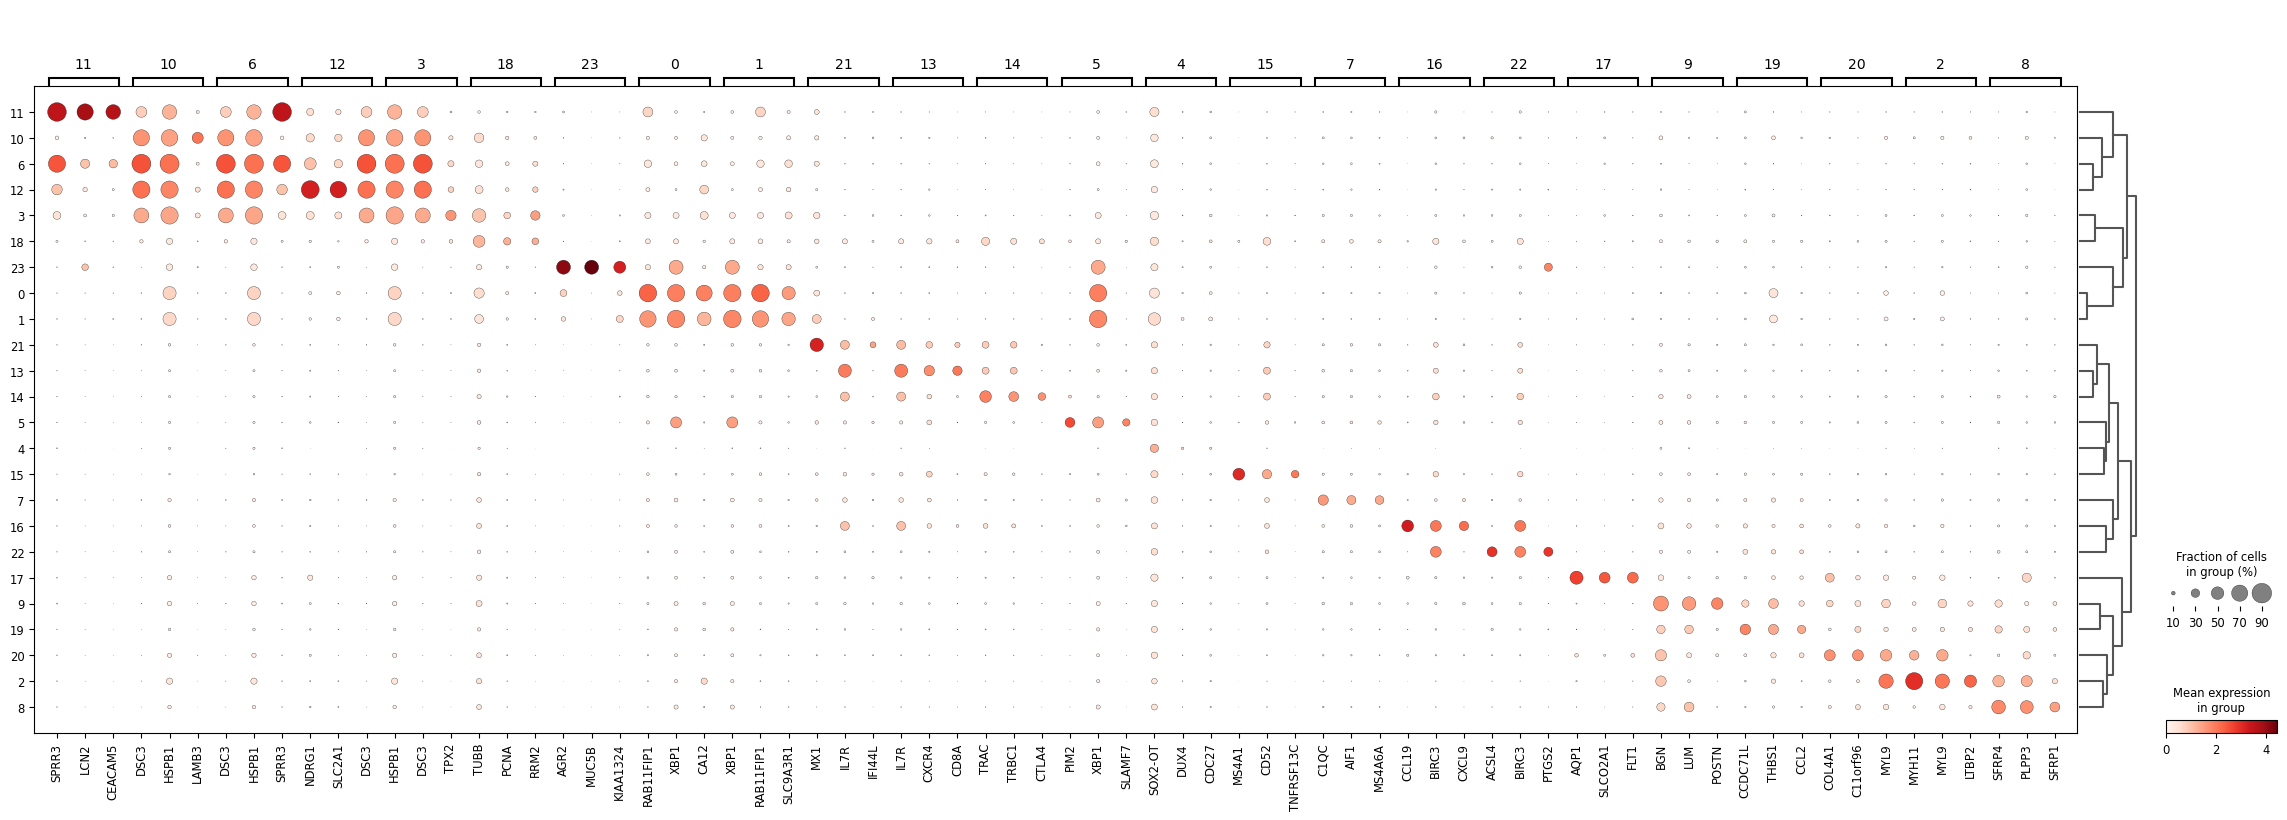

CPU times: user 49 s, sys: 1.43 s, total: 50.5 s
Wall time: 23.2 s


In [39]:
%%time
sc.tl.rank_genes_groups(adata, groupby="leiden", layer="lognorm", pts=True)

sc.pl.rank_genes_groups_dotplot(adata, n_genes=3)

##  Section 3.7 Subset for macrophages

Below we subset macrophages only and compare gene expression in macrophage between breast cancer and cervical cancer data. The demonstration below is for explorative purposes to compare macrophages between two tissues. The p-value obtained from this analysis should be interpreted with caution, because these tests treat each bin as an independent replicate, which could cause false positives.

Note: for a robust experimental design, you need independent biological replicates to make valid scientific claims about a population.

In biological experiments, particularly in gene expression studies, replicates are essential to ensure the results are reliable and not just due to random chance or experimental error.
Why do we need at least 3 replicates?
A minimum of three replicates (often called "triplicates") is the standard because it is the smallest number that allows for basic statistical validation: 
Calculating Variation: You need at least two data points to calculate a mean, but a third point is required to calculate a standard deviation or variance.
Identifying Outliers: If you only have two replicates and they are wildly different, you cannot know which one is "correct". With three, if two are similar and one is an outlier, you have a better basis for identifying the error.
Statistical Power: Moving from 2 to 3 samples provides a significant jump in statistical power (the ability to detect a true effect), while moving from 3 to 4 provides diminishing returns compared to the added cost.

Why do independent replicates prevent false positives?
    An independent replicate (or biological replicate) comes from an entirely separate biological source, such as a different patient or a different batch of cells. Treating non-independent data as independent causes false positives because: 
        1. Artificial Sample Size: If you treat 1,000 cells from a single patient as 1,000 independent samples, your statistical test will think your "n" is 1,000. In reality, your "n" is 1 (the patient).
        2. Underestimated Variance: Cells from the same person share the same genetics and environment, so they are more similar to each other than to cells from another person. Ignoring this makes your data look much more consistent than it actually is, leading to "improbably low" p-values that suggest a significant difference where none exists. 

Is there such a thing as a non-independent replicate?
    Yes, these are often called pseudoreplicates or technical replicates: 
    Technical Replicate: Taking the same sample and running it through a machine twice. This only tests how precise the machine is, not the biological reality of the population.
    Pseudoreplicate: In single-cell studies (like the macrophage example), individual cells from the same tissue sample are considered pseudoreplicates. They are useful for seeing diversity within one person, but they cannot be used alone to make claims about "breast cancer" vs. "cervical cancer" as a whole without multiple independent patients.

Summary of Replicate Types
Replicate_Type 	            Source	                    Purpose	        Conclusion
Independent (Biological)	Different patients/animals;	Tests if the result is true for the population	Essential for good design
Technical	                Same sample, measured twice;	Tests if the machine/protocol is precise	Good for QC, but not for "n"
Pseudoreplicate	            Different cells from one sample	Tests internal diversity within one unit	Causes false positives if treated as independent


A more robust statistic test for differential expression genes (DEG) between conditions requires biological replicates (at least 3 biological replicates per condition are recommended) and pseudo-bulk DEG analysis approach can be used for this analysis. 

Differential Gene Expression Analysis in scRNA-seq Data between Conditions with Biological Replicates
Use PyDESeq2 for pseudo-bulk DE analysis


In [40]:
adata_macrophages = adata[adata.obs.leiden == "5"].copy()

Re-do analyses: Find variable genes, data normalization and scaling, PCA, Harmony batch correction (on PCA), UMAP and clustering on macrophage cells only.

In [41]:
%%time
adata_macrophages.X = adata_macrophages.layers["counts"].copy()
sc.pp.highly_variable_genes(adata_macrophages, n_top_genes=2000, flavor="seurat_v3")
sc.pp.normalize_total(adata_macrophages)
sc.pp.log1p(adata_macrophages)

adata_macrophages.layers["lognorm"] = adata_macrophages.X.copy()

sc.pp.scale(adata_macrophages, zero_center=False, max_value=10)
sc.pp.pca(adata_macrophages, n_comps=30)

CPU times: user 2.31 s, sys: 66.1 ms, total: 2.37 s
Wall time: 693 ms


In [42]:

import harmonypy as hm

ho = hm.run_harmony(
    adata_macrophages.obsm["X_pca"],
    adata_macrophages.obs,
    "tissue"
)

adata_macrophages.obsm["X_pca_harmony"] = ho.Z_corr

sc.pp.neighbors(adata_macrophages, use_rep="X_pca_harmony")
sc.tl.umap(adata_macrophages)



2026-03-11 20:37:00,504 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-03-11 20:37:00,505 - harmonypy - INFO -   Parameters:
2026-03-11 20:37:00,505 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-11 20:37:00,506 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-11 20:37:00,506 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-11 20:37:00,506 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-11 20:37:00,507 - harmonypy - INFO -     nclust: 100
2026-03-11 20:37:00,507 - harmonypy - INFO -     block_size: 0.05
2026-03-11 20:37:00,508 - harmonypy - INFO -     lamb: [1. 1.]
2026-03-11 20:37:00,509 - harmonypy - INFO -     theta: [2. 2.]
2026-03-11 20:37:00,510 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-11 20:37:00,510 - harmonypy - INFO -     verbose: True
2026-03-11 20:37:00,511 - harmonypy - INFO -     random_state: 0
2026-03-11 20:37:00,511 - harmonypy - INFO -   Data: 30 PCs × 29808 cells
2026-03-11 20:37:00,511 - harmonypy - INFO

2026-03-11 20:37:00,851 - harmonypy - INFO - KMeans initialization complete.
2026-03-11 20:37:00,981 - harmonypy - INFO - Iteration 1 of 10
2026-03-11 20:37:09,960 - harmonypy - INFO - Iteration 2 of 10
2026-03-11 20:37:19,042 - harmonypy - INFO - Converged after 2 iterations


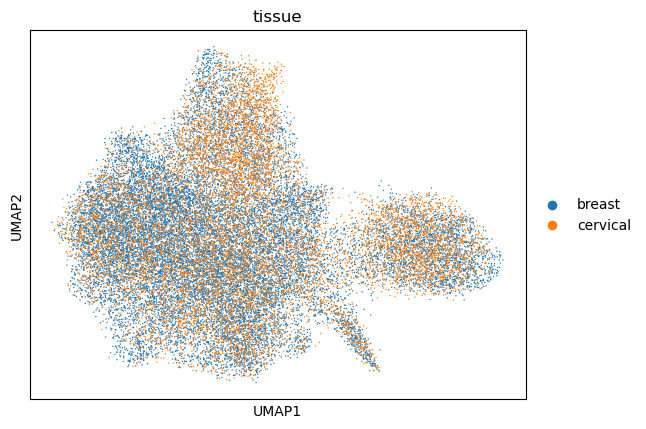

In [43]:
sc.pl.umap(adata_macrophages, color=["tissue"], vmax="p99")

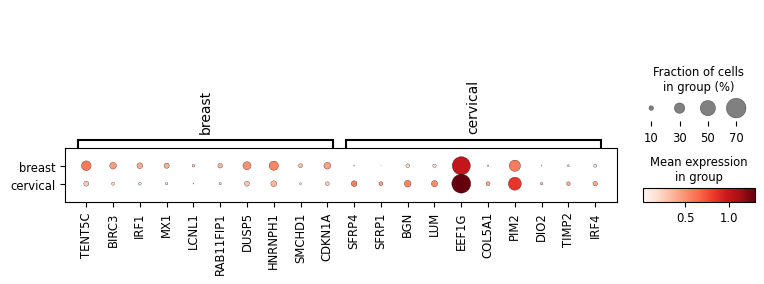

In [44]:
sc.tl.rank_genes_groups(
    adata_macrophages, groupby="tissue", layer="lognorm", pts=True
)

sc.pl.rank_genes_groups_dotplot(adata_macrophages)

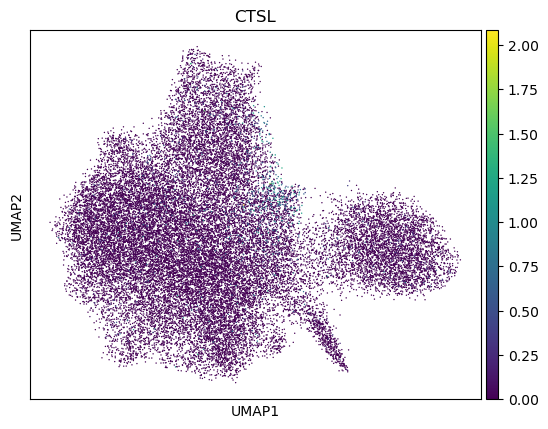

In [51]:
sc.pl.umap(adata_macrophages, color="CTSL", layer="lognorm")

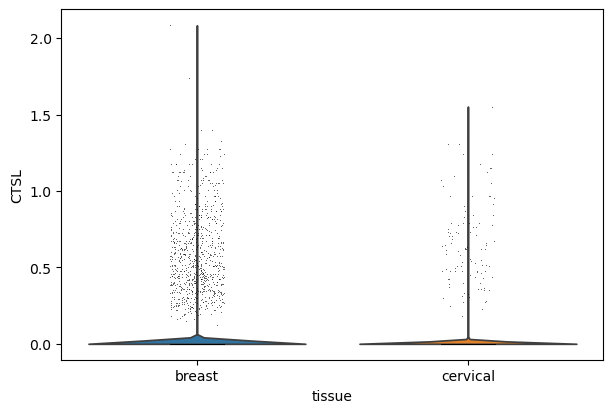

In [52]:
sc.pl.violin(
    adata_macrophages, groupby="tissue", keys="CTSL", layer="lognorm", size=0.5
)

# 4. [Additional Topics] Neighbors enrichment analysis

Here, we return to the Xenium Breast Cancer results in Section 2 to show a simple neighborhood enrichment analysis. Although, we did not annotate the cell types in the following section, we would recommend first annotating cell types in your own analysis.

In [53]:
import squidpy as sq
import anndata as ad
import matplotlib.pyplot as plt

In [55]:
sdata = sd.read_zarr("./breast_cancer/breast_processed.zarr")
adata = sdata["table"]

## Section 4.1 Building a spatial neighborhood graph

We calculate the centrality scores for each cell or spot using the clustering labels provided in adata.obs["leiden"]. Centrality measures how "important" a cluster is within the graph, providing an overall picture of which clusters might be important.

Average clustering - Measures the tendency of nodes within the cluster to form triangles. High values suggest tight-knit groups, often found in localized tissue regions or co-expressing gene modules.

Closeness centrality - How close a cluster is, on average, to all other clusters in the graph. A cluster with high closeness may act as a mediator or integrator, potentially central in tissue structure or cell–cell communication.

Degree centrality - The fraction of edges from group members that connect to non-group members. High inter-group degree centrality indicates outward-facing influence. These clusters may be key in interacting with other cell types or regions.

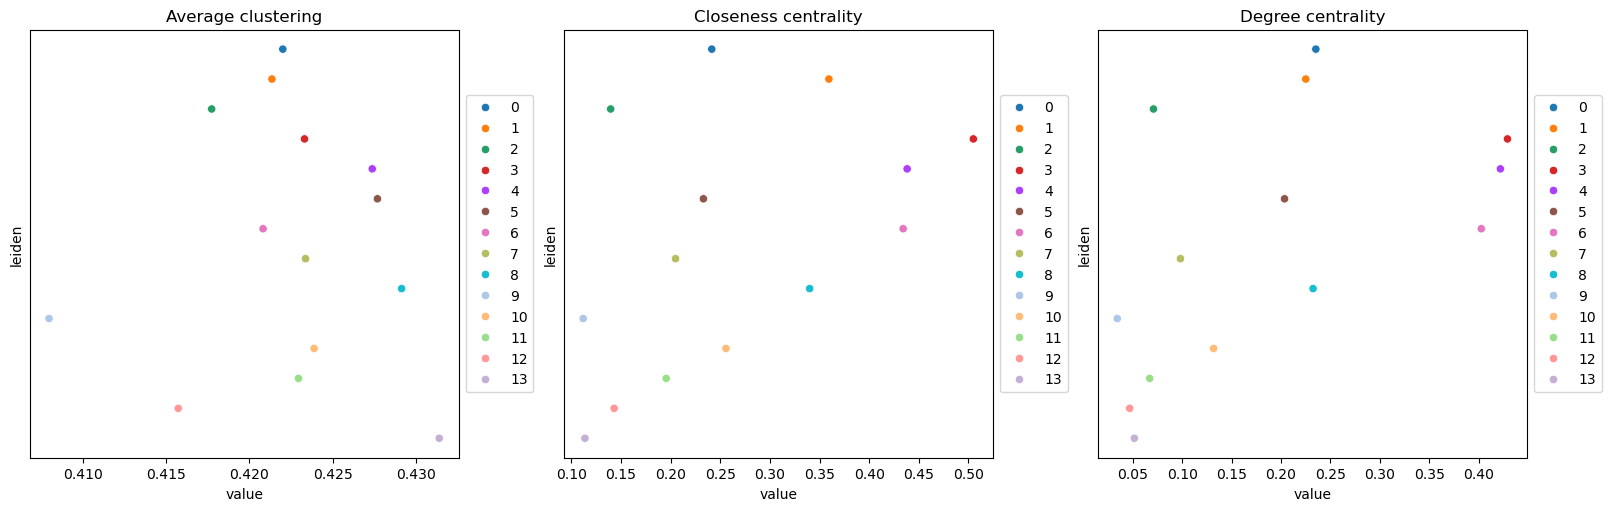

In [56]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

# Compute centrality scores
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16,5))



### Section 4.2 Neighbors enrichment analysis  


Neighborhood enrichment analysis calculates an enrichment score by assessing the proximity of cell clusters on the connectivity graph. This score is then compared to a distribution generated through permutations, and a z-score is calculated based on the observed versus expected number of events.

Below, cluster 3 shows the highest self-enrichment, meaning it is most frequently found near itself

MemoryError: Unable to allocate 915. GiB for an array with shape (495704, 495704) and data type int32

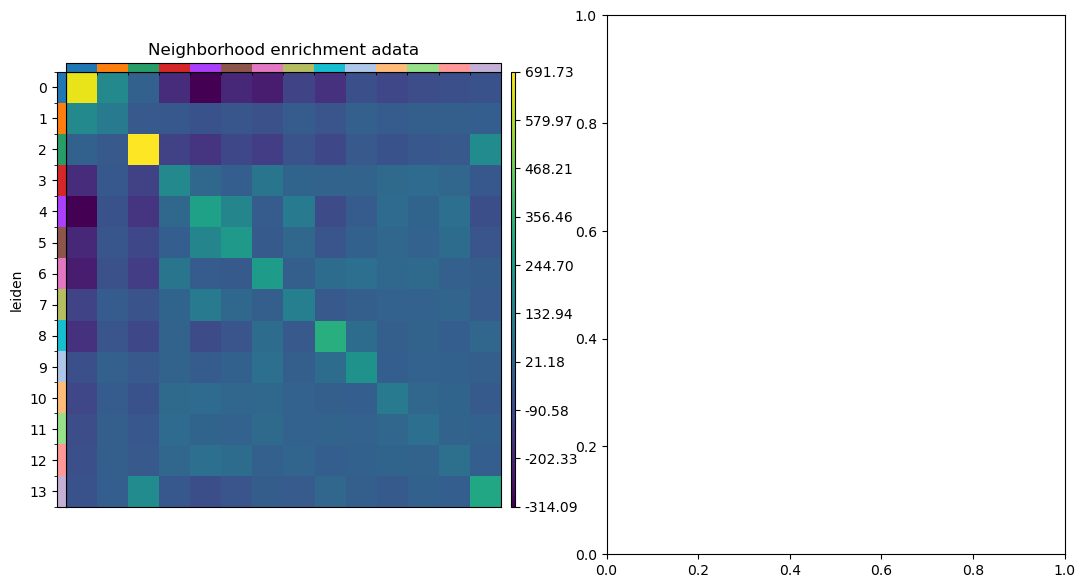

In [58]:
#sq.gr.nhood_enrichment(adata, cluster_key="leiden")

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8,8),
    title="Neighborhood enrichment adata",
    ax=ax[0]
)

sdata.pl.render_shapes("cell_boundaries", color="leiden").pl.show(ax=ax[1])


### Section 4.3 Identify Spatially Variable genes/features (SVF) by Moran's I score


A gene with the highest Moran's I score in a spatial transcriptomics dataset is a prime example of a spatially variable gene that exhibits strong, non-random, and clustered expression. This makes it a valuable candidate for understanding tissue organization, identifying spatial domains, and inferring biological functions linked to specific locations within the tissue.




In [61]:
%%time
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    n_jobs=-1,
)
adata.uns['moranI'].head(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
XBP1,0.397333,0.0,6.835433e-07,0.0
CA12,0.375674,0.0,6.835433e-07,0.0
RAB11FIP1,0.375518,0.0,6.835433e-07,0.0
TSPAN13,0.299253,0.0,6.835433e-07,0.0
IGSF1,0.298321,0.0,6.835433e-07,0.0
ANKRD30A,0.274479,0.0,6.835433e-07,0.0
TCIM,0.270507,0.0,6.835433e-07,0.0
SERPINA3,0.256498,0.0,6.835433e-07,0.0
MYH11,0.251630,0.0,6.835433e-07,0.0
NPY1R,0.236942,0.0,6.835433e-07,0.0


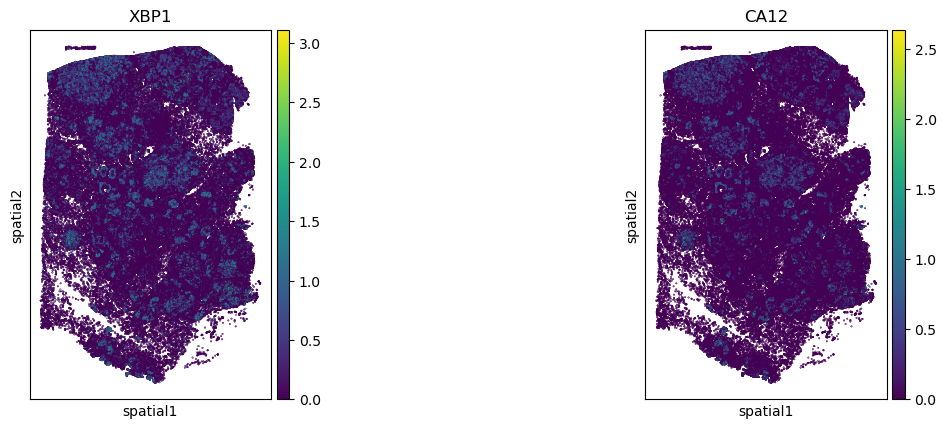

In [60]:
# We can visualize some of those genes with squidpy.pl.spatial_scatter.

sq.pl.spatial_scatter(
    adata,
    library_id = "spatial",
    color=["XBP1", "CA12"],
    shape=None,
    img=False,
    layer="lognorm"
)
